In [1]:
import pandas as pd

In [2]:
train_df = pd.read_csv('../results/outputs/Selected/train_top10_features.csv')
test_df = pd.read_csv('../results/outputs/Selected/test_top10_features.csv')

train_df_pca = pd.read_csv('../results/outputs/PCA/pca_train.csv')
test_df_pca = pd.read_csv('../results/outputs/PCA/pca_test.csv')

In [3]:
feature_cols = [c for c in train_df.columns if c != "target"]

x_train = train_df[feature_cols]
y_train = train_df["target"]

x_test = test_df[feature_cols]
y_test = test_df["target"]

In [4]:
feature_cols = [c for c in train_df_pca.columns if c != "target"]

x_train_pca = train_df_pca[feature_cols]
y_train_pca = train_df_pca["target"]

x_test_pca = test_df_pca[feature_cols]
y_test_pca = test_df_pca["target"]

In [7]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
#First train with the ANOVA-10 features

In [8]:
gb = HistGradientBoostingClassifier(random_state=42)
gb.fit(x_train, y_train)

gb_preds = gb.predict(x_test)
gb_accuracy = accuracy_score(y_test, gb_preds)

print("Gradient Boosting Accuracy:", gb_accuracy)
print(classification_report(y_test, gb_preds))

Gradient Boosting Accuracy: 0.8727272727272727
              precision    recall  f1-score   support

           0       0.89      0.85      0.87        74
           1       0.87      0.90      0.88        72
           2       0.86      0.86      0.86        74

    accuracy                           0.87       220
   macro avg       0.87      0.87      0.87       220
weighted avg       0.87      0.87      0.87       220



In [ ]:
#Try with PCA features

In [9]:
gb_pca = HistGradientBoostingClassifier(random_state=42)
gb_pca.fit(x_train_pca, y_train_pca)

gb_preds_pca = gb_pca.predict(x_test_pca)
gb_accuracy_pca = accuracy_score(y_test_pca, gb_preds_pca)

print("Gradient Boosting Accuracy (PCA):", gb_accuracy_pca)
print(classification_report(y_test_pca, gb_preds_pca))

Gradient Boosting Accuracy (PCA): 0.8818181818181818
              precision    recall  f1-score   support

           0       0.88      0.89      0.89        74
           1       0.84      0.89      0.86        72
           2       0.93      0.86      0.90        74

    accuracy                           0.88       220
   macro avg       0.88      0.88      0.88       220
weighted avg       0.88      0.88      0.88       220



In [ ]:
#So with PCA accuracy is higher so sticking to PCA
#Moving to hyperparameter tuning for PCA features

In [10]:
from sklearn.model_selection import GridSearchCV

In [11]:
param_grid = {
    "learning_rate": [0.03, 0.1, 0.2],
    "max_depth": [2, 3, None],
    "max_iter": [100, 200],
    "l2_regularization": [0, 1, 10],
    "min_samples_leaf": [20, 40],
}

grid_gb = GridSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_gb.fit(x_train_pca, y_train_pca)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,estimator,HistGradientB...ndom_state=42)
,param_grid,"{'l2_regularization': [0, 1, ...], 'learning_rate': [0.03, 0.1, ...], 'max_depth': [2, 3, ...], 'max_iter': [100, 200], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [12]:
best_gb = grid_gb.best_estimator_

print("Best GB parameters:", grid_gb.best_params_)
print("Best GB CV accuracy:", grid_gb.best_score_)

Best GB parameters: {'l2_regularization': 10, 'learning_rate': 0.03, 'max_depth': 2, 'max_iter': 100, 'min_samples_leaf': 20}
Best GB CV accuracy: 0.8795454545454545


In [13]:
tuned_gb_preds = best_gb.predict(x_test_pca)
tuned_gb_accuracy = accuracy_score(y_test_pca, tuned_gb_preds)

print("Tuned GB Test Accuracy:", tuned_gb_accuracy)
print(classification_report(y_test_pca, tuned_gb_preds))

Tuned GB Test Accuracy: 0.8863636363636364
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        74
           1       0.86      0.89      0.88        72
           2       0.89      0.86      0.88        74

    accuracy                           0.89       220
   macro avg       0.89      0.89      0.89       220
weighted avg       0.89      0.89      0.89       220



In [14]:
tuned_gb_preds_train = best_gb.predict(x_train_pca)
print("Tuned GB Train Accuracy:", accuracy_score(y_train_pca, tuned_gb_preds_train))

Tuned GB Train Accuracy: 0.9056818181818181


In [15]:
import joblib
joblib.dump(best_gb, "../results/model_trained_files/gradient_boosting_model.pkl")

['../results/model_trained_files/gradient_boosting_model.pkl']

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

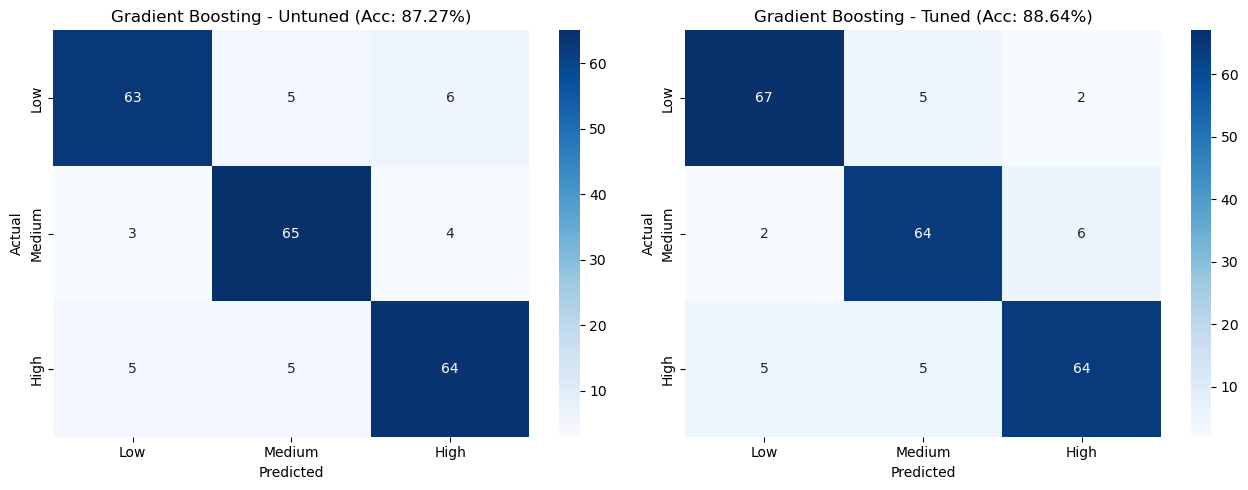

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_tn = confusion_matrix(y_test_pca, tuned_gb_preds)

cm_unt = confusion_matrix(y_test_pca, gb_preds)
sns.heatmap(cm_unt, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
axes[0].set_title(f"Gradient Boosting - Untuned (Acc: {gb_accuracy:.2%})")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_tn, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
axes[1].set_title(f"Gradient Boosting - Tuned (Acc: {accuracy_score(y_test_pca, tuned_gb_preds):.2%})")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("../results/eda_visualizations/gb_confusion_comparison_tuned_vs_untuned.png", dpi=150, bbox_inches='tight')
plt.show()